## Examples: Gaussian mixture models

#### In this notebook, we'll learn about soft or fuzzy clustering techniques, how the Gaussian mixture model works, and how to perform GMM clustering using sklearn.

### **Learning Objectives**
#### By the end of this notebook, you should be able to:
#### - Learn how to fit a generative model to some data
#### - Learn how to use Gaussian mixture models (GMMs) to cluster data
#### - Understand the Expectation Maximisation algorithm
#### - Implement GMMs in sklearn

### Fitting a Gaussian distribution - 1D example

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
# 1D data with N = 100 samples
X = np.array([ 0.4690433 ,  1.77247772, -0.79937833,  2.08347278,  0.96008571,
                0.84984587,  2.53514641, -1.77954757, -0.2197194 , -0.24392515,
               -1.45156281,  0.05793749,  1.22118967,  0.69298749, -1.95318449,
                0.46780091,  1.48841197,  0.03489486, -0.71973614,  0.78253223,
               -1.10623475, -1.39394697,  1.43624876,  0.0722706 ,  1.62888107,
               -0.61214466, -2.86427397, -1.01435684,  0.18012821, -0.43215255,
                1.40345509,  0.40500954, -0.1878166 ,  1.39892911, -0.30331199,
               -1.24989628,  0.05717373,  0.20798511, -0.75087319, -0.96573914,
               -0.83499918,  0.95337156, -0.03423916, -0.2720539 ,  0.852107  ,
                0.36567677,  1.56131278,  0.50956683, -0.20242891, -0.50132433,
               -0.39382268, -0.99104849, -1.11567828, -0.21453752,  0.49848449,
               -1.09310205, -0.09755406,  0.77719942, -1.18284674, -0.02979667,
               -0.54815865,  1.2200912 , -0.51472699,  0.83554114, -1.62354525,
               -1.03256075,  0.800314  , -0.41924884, -0.77253838, -0.32138824,
                1.22731845, -0.30567561,  0.19722008, -0.46858797,  0.56092996,
               -1.66687179,  0.50654635,  1.68834199, -0.12608541,  1.88398685,
               -1.02705767, -1.0139658 ,  0.94250101, -0.2120914 , -0.32842348,
                0.15071674,  0.21345239, -0.23936087, -1.35388172, -0.60518554,
                0.61064511,  0.11129081,  1.18438721,  0.51317973, -2.59507755,
               -1.08846815, -2.10072134,  0.10113415, -0.75070778,  0.45416333])

In [3]:
mean = np.mean(X)
variance = np.var(X, ddof=1)
print("mean = ", mean, "\nVariance = ", variance)

mean =  -0.05200175000000003 
Variance =  1.086265726774446


In [5]:
# create hypothesis function
def hypothesis(x, mean, var):
    C = 1/np.sqrt(2 * np.pi * var)
    return C * np.exp(-((mean - x) ** 2) / (2 * var))

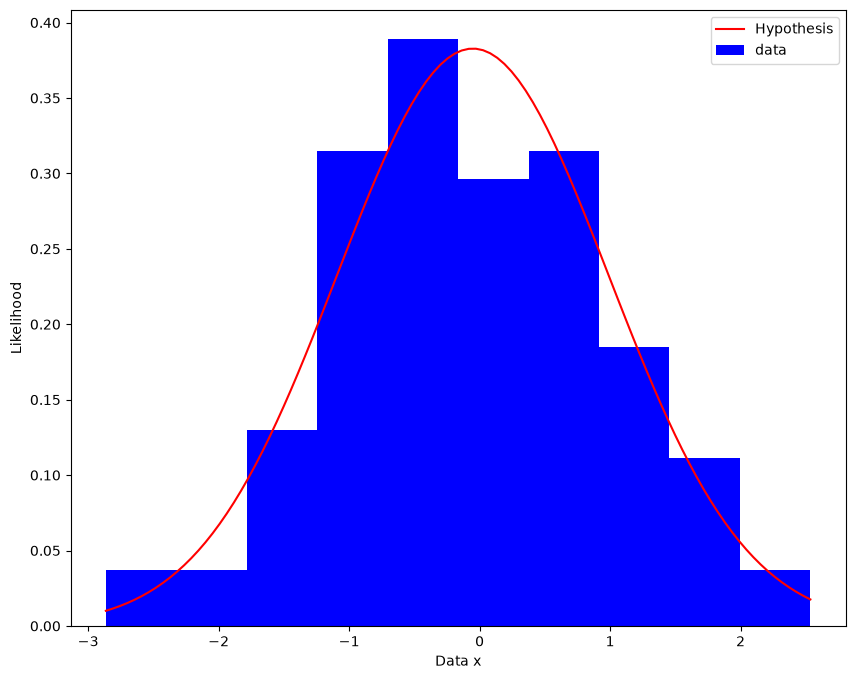

In [7]:
plt.figure(figsize=(10, 8))

# evaluate hypothesis at every point between smallest and largest x
domain = np.linspace(np.min(X), np.max(X), num=100)
hyp = hypothesis(domain, mean, variance)
plt.plot(domain, hyp, 'red', label='Hypothesis')

# plot histogram of data
plt.hist(X, density=True, color='blue', label='data')
plt.legend()
plt.xlabel('Data x')
plt.ylabel('Likelihood')

plt.show()

### Fitting a Gausian distribution - 2D example

In [8]:
X = np.array([[ 1.18405449, -0.61883635],[ 0.82303412,  2.34545237],[ 0.42673046,  0.48581614],[-2.23450477,  0.2532654 ],[-2.23450477,  0.2532654 ],
            [-2.23450477,  0.2532654 ], [-0.28640509,  0.21023263], [ 0.63967181,  0.85205666], [ 0.42823605,  0.95335968], [ 0.3970288 , -0.11228348],
            [-2.09185064,  0.52349849], [ 0.336873  ,  0.07290918], [-0.17059836,  0.08075803], [-0.59336044,  1.04711674], [-0.0424399 , -0.59228045],
            [ 1.22920971, -0.11090265], [ 1.8747326 , -0.70050876], [-0.0494112 ,  0.43354407], [-0.8762429 ,  0.30484824], [ 0.78497093,  0.30996722],
            [ 0.45326148, -1.67663979], [-0.83121756,  0.84094015], [ 0.52141093, -0.16207117], [-0.52108727,  0.06136304], [ 0.72282484, -1.0194738 ],
            [ 0.2657052 , -0.23948218], [-1.74456399, -0.43014042], [ 0.91864104, -1.12071598], [ 1.57170977, -0.74164349], [-0.41335287,  0.95045059],
            [ 0.64302235,  0.02411848], [-1.76686324,  1.15590427], [ 0.71301054,  0.56447212], [ 0.60803609, -0.46964791], [-2.05930665, -0.8287741 ],
            [-0.12545787,  1.49615772], [ 1.64737054,  1.39309602], [ 0.61428088,  1.83653766], [ 0.35183602,  1.21764892], [ 0.69285859, -0.26966068],
            [-0.82625094, -0.11233266], [ 0.22153869, -0.22230833], [ 1.48555395, -2.26605394], [-1.1842873 , -0.6015293 ], [-0.42801843, -1.85755166],
            [-0.6266858 , -0.10940033], [-0.85912054, -1.45635312], [-0.50489495,  2.68371611], [ 0.37835896, -0.9543046 ], [ 0.25337114, -1.90642799],
            [ 0.9070055 ,  2.21987351], [ 0.2416872 , -0.46277313], [ 1.3096389 ,  1.38041353], [-0.77880778,  1.44810663], [ 0.01946108,  1.34767778],
            [-1.10334462, -0.3236939 ], [-0.10999428, -0.6620466 ], [-0.27887276,  1.64339159], [-1.59708175,  0.17844474], [-0.15366357,  0.47804623],
            [-0.08232383,  1.47403718], [-1.37151635, -0.24102183], [-0.15888604,  0.58106303], [ 0.08347985,  2.10064311], [ 0.68151704,  0.1532785 ],
            [ 1.30449518,  1.00066168], [-2.00121055,  0.66646458], [-1.19761629, -0.98489152], [ 0.58517698,  1.94988805], [-0.72059476, -1.40765373],
            [ 0.76408769,  1.91394767], [-1.82452629, -1.48230873], [ 0.73812697,  1.46300466], [ 0.50905436, -1.06867973], [ 1.27993371, -1.23583931],
            [-0.08579759,  1.16789507], [-0.62528843, -0.12227063], [-0.85997776,  0.34879629], [-0.18332512,  0.93899945], [-1.08683726,  1.18691834],
            [ 0.33477969, -0.78255199], [-0.81856565, -2.2604502 ], [-0.11159687, -0.78372415], [-0.26750993, -0.90687657], [-0.07519719,  0.31169849],
            [-0.55479307, -0.84408206], [ 2.16397526,  1.86725312], [ 1.00039999, -0.57044739], [-1.12102751, -0.31039134], [-0.29435841, -0.04115669],
            [ 1.36460232,  2.49310119], [ 0.24690957,  1.48624123], [-1.61849178, -0.69307334], [ 0.18234863,  1.02038581], [-0.6665022 ,  1.34464121],
            [ 0.4542274 , -0.79833642], [-0.77347234,  0.58513183], [-0.72188959, -0.8124402 ], [ 1.73213478,  0.2254615 ]])

In [9]:
mean_vector = np.mean(X, axis=0)
covariance = np.cov(X.T, ddof=1)
print("mean vector: \n", mean_vector, "\ncovariance: \n", covariance)

mean vector: 
 [-0.07936995  0.18389085] 
covariance: 
 [[1.01539884 0.13251138]
 [0.13251138 1.21247087]]


In [10]:
def hypothesis(X, mu, cov):
    result = []
    part1 = 1 / ( ((2 * np.pi) ** (len(mu) / 2)) * (np.linalg.det(cov) ** ( 1 / 2)))
    for x in X.T:
        part2 = (-1/2) * ((x - mu).T.dot(np.linalg.inv(cov))).dot((x-mu))
        result.append(part1 * np.exp(part2))
    return np.array(result)

In [11]:
# generate points arranged in a grid for evaluating the hypothesis
num = 100
xx, yy = np.meshgrid(np.linspace(-5, 5, num), np.linspace(-5, 5, num))
domain = np.vstack((xx.ravel(), yy.ravel())).T

In [14]:
# evaluate hypothesis at every point in the grid
hyp = hypothesis(domain.T, mean_vector, covariance)
im = hyp.reshape((num, num))

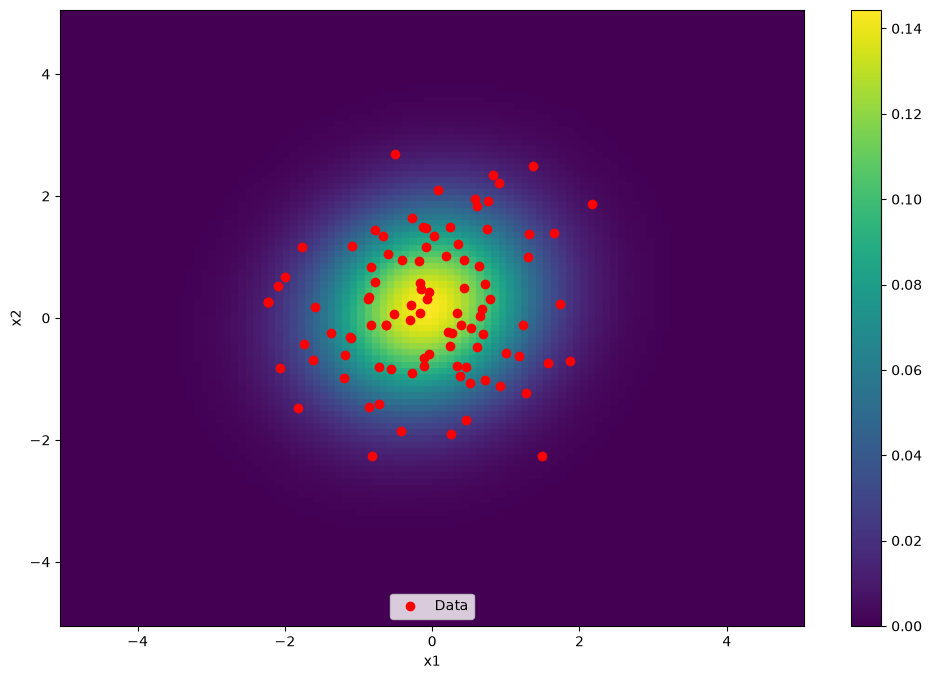

In [17]:
# visualise the hypothesis as a heatmpa and compare against the data
plt.figure(figsize=(12, 8))
plt.pcolor(xx, yy, im)
plt.colorbar()
plt.scatter(
    X[:, 0],
    X[:, 1],
    label='Data',
    c='red'
)
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()

### Gaussian mixture model clustering in sklearn

In [19]:
import numpy as np
import pandas as pd
import datetime
from sklearn import preprocessing
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# plotting
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Text(0, 0.5, 'Feature 2')

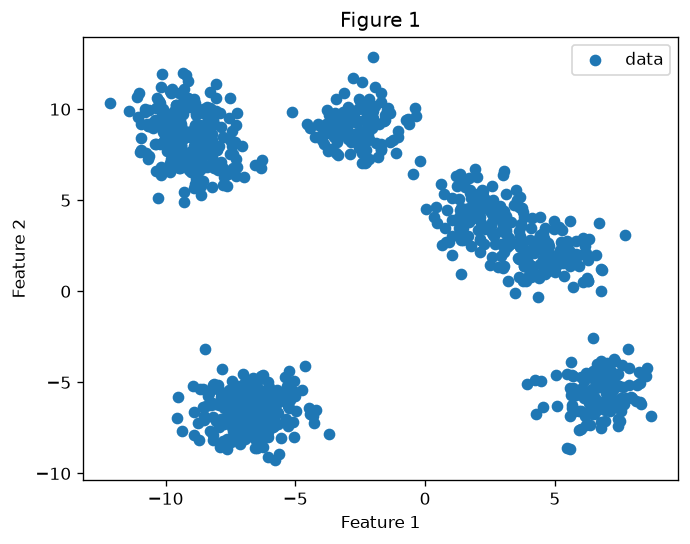

In [20]:
# amke 8 blobs in 2D space
n_features = 2
centers = 8


X, y = make_blobs(
    n_samples=1000,
    centers=centers,
    n_features=n_features,
    random_state=42
)

df = pd.DataFrame(
    X,
    columns=[*[f'feature_{i}' for i in range(n_features)]]
)

# plot data
plt.figure(dpi=120)
x1 = df['feature_0']
x2 = df['feature_1']
plt.scatter(x1, x2, label='data')

plt.legend()
plt.title('Figure 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

### Preprocessing the data

In [21]:
# create scaler object
scaler = StandardScaler()

# Scale the data
X_scaled = scaler.fit_transform(df)

### Implement Gaussian mixture model clustering algorithm

In [22]:
from sklearn.mixture import GaussianMixture

In [23]:
K = 8

In [24]:
# Create the GMM instance
GMM = GaussianMixture(n_components=K, random_state=42)

# Use the object to fit the algorithm
GMM.fit(X_scaled)

# Predict in which cluster each data point falls
GMM_pred = GMM.predict(X_scaled)

In [25]:
df['cluster_label'] = GMM_pred

Text(0, 0.5, 'Feature 2')

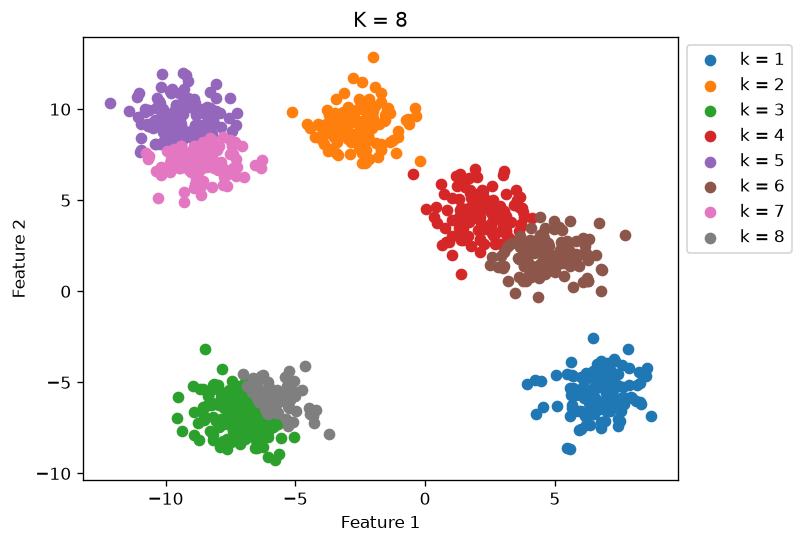

In [39]:
# Plot data
plt.figure(dpi=120)
for k in range(K):
    x1 = df[df['cluster_label'] == k]['feature_0']
    x2 = df[df['cluster_label'] == k]['feature_1']
    plt.scatter(x1, x2, label="k = "+str(k+1))

plt.legend(loc=0, bbox_to_anchor=(1, 1))
plt.title("K = 8")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

### Cluster probabilities

In [40]:
GMM.predict_proba(X_scaled)

array([[9.89259104e-53, 5.62953462e-67, 9.92461907e-01, ...,
        8.26210963e-58, 2.96259704e-58, 7.53809267e-03],
       [1.91318079e-60, 6.55548924e-37, 9.75892125e-01, ...,
        3.18417049e-40, 1.00702807e-24, 2.41078746e-02],
       [2.33348134e-46, 1.13455453e-57, 8.04338167e-01, ...,
        5.78711176e-48, 7.32943169e-51, 1.95661833e-01],
       ...,
       [2.35506023e-42, 5.58015925e-62, 8.60572933e-01, ...,
        3.95333660e-49, 9.66866934e-57, 1.39427067e-01],
       [3.26983517e-47, 2.03814175e-60, 9.01937590e-01, ...,
        2.33372277e-50, 2.11482638e-53, 9.80624096e-02],
       [2.26867680e-27, 3.22601726e-11, 7.77163665e-69, ...,
        1.52509795e-03, 1.64858421e-29, 1.76115407e-59]], shape=(1000, 8))